<a href="https://colab.research.google.com/github/bygencer3/ErdincGencer_Odev_254329028-/blob/main/Erdinc_Gencer_254329028_YapayZekaveUyg_Odev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ÜSKÜDAR ÜNİVERSİTESİ FEN BİLİMLERİ ENSTİTÜSÜ YAPAY ZEKA MÜHENDİSLİĞİ YÜKSEK LİSANS BÖLÜMÜ



YAPAY ZEKA VE UYGULAMALARI DERSİ VİZE ÖDEVİ

KONU: KREDİ RİSK DEĞERLENDİRME SİSTEMİ


HAZIRLAYAN: ERDİNÇ GENÇER

ÖĞRENCİ NO: 254329028

ÖĞRETİM GÖREVLİSİ: DR. SERKAN EMEK



**Kredi Risk Değerlendirme Sistemi**

Bu proje, denetimli öğrenme (supervised learning) tekniklerini kullanarak, bir bankanın müşteri verileri üzerinden kredi geri ödeme riskini tahmin etmeye ve riskli başvuruları önceden belirlemeye odaklanır.

**Kullanılan Yöntemler:**

* Sınıflandırma Algoritmaları: Temel ve doğrusal bir model olan Logistic
Regression'ın yanı sıra, daha karmaşık yapıları çözmek için topluluk öğrenme modelleri olan Random Forest ve XGBoost algoritmaları kullanılmıştır.

* Model Değerlendirme: Modellerin sadece başarısını değil, hata türlerini de görmek için Confusion Matrix (Karmaşıklık Matrisi) ve genel başarı için Accuracy (Doğruluk) skorları analiz edilmiştir.

* Hiperparametre Optimizasyonu: Modellerin performansını en üst düzeye çıkarmak için GridSearchCV kullanılmış ve kararlılığı ölçmek amacıyla Cross-validation (Çapraz Doğrulama) uygulanmıştır.

* Özellik Önem Analizi: Modelin karar verme sürecini şeffaflaştırmak için hangi değişkenlerin (gelir, yaş, kredi geçmişi vb.) tahminde daha etkili olduğunu gösteren Feature Importance analizi yapılmıştır.

**Gereklilikler:**

* Denetimli öğrenme ve sınıflandırma (classification) teorisi bilgisi.

* Veri işleme için Pandas ve gelişmiş makine öğrenmesi modelleri için Scikit-learn ve XGBoost kütüphanelerinin kullanımı.

* Model performans metriklerini yorumlayabilme ve görselleştirme yetkinliği.

**Hedeflenen Çıktılar:**

* Verideki özelliklerden yola çıkarak "Kredi Onay" veya "Kredi Red" kararlarını yüksek doğrulukla tahmin eden bir yapı kurmak.

* Farklı algoritmaları (Logistic Regression vs. Random Forest) karşılaştırarak veri setine en uygun modeli matematiksel verilerle seçmek.

* Bankacılık sektörü için riskli müşteri profilini tanımlayan en önemli kriterleri (Feature Importance) belirlemek.

**Karşılaşılabilecek Zorluklar:**

* Dengesiz Veri Seti (Imbalanced Data): Gerçek hayatta kredi ödemeyenlerin sayısının çok az olması nedeniyle modelin "herkese onay verme" eğilimine girmesini ve ezberlemesini (overfitting) engellemek.

* Hata Maliyeti: Bir banka için "krediyi ödemeyecek birine onay vermek" (Yanlış Pozitif), "ödeyecek birine red vermek"ten daha maliyetli olduğu için modelin bu dengeyi kurmasını sağlamak.

* Model Yorumlanabilirliği: Karmaşık modellerin (XGBoost gibi) neden "red" kararı verdiğini banka regülasyonlarına uygun şekilde açıklanabilir hale getirmek.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pandas as pd

# Gerçek "German Credit Risk" veri setini çekiyoruz
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"
columns = ['Gelir_Durumu', 'Kredi_Suresi', 'Kredi_Gecmisi', 'Amac', 'Kredi_Miktari',
           'Tasaruflar', 'Istihdam_Suresi', 'Taksit_Orani', 'Kisisel_Durum', 'Diger_Borclular',
           'Ikamet_Suresi', 'Degerli_Varlik', 'Yas', 'Diger_Taksitler', 'Konut',
           'Mevcut_Krediler', 'Is', 'Bakmakla_Yukumlu', 'Telefon', 'Yabanci_Isci', 'Kredi_Onay']

df_kredi = pd.read_csv(url, sep=r'\s+', names=columns)

# Hedef değişkeni (Kredi_Onay) 0 ve 1 yapalım (1: İyi, 2: Kötü geldiği için düzeltiyoruz)
df_kredi['Kredi_Onay'] = df_kredi['Kredi_Onay'].replace({1: 1, 2: 0})

print("Gerçek Veri Seti Yüklendi. Satır/Sütun Sayısı:", df_kredi.shape)
df_kredi.head()

Gerçek Veri Seti Yüklendi. Satır/Sütun Sayısı: (1000, 21)


Gelir_Durumu  Kredi_Suresi  Kredi_Gecmisi  Amac  Kredi_Miktari  \
1 6  4 12             5             5              3     4              1   
2 48 2 60             1             3              2     2              1   
4 12 4 21             1             4              3     3              1   
1 42 2 79             1             4              3     4              2   
  24 3 49             1             3              3     4              4   

           Tasaruflar  Istihdam_Suresi  Taksit_Orani  Kisisel_Durum  \
1 6  4 12          67                3             2              1   
2 48 2 60          22                3             1              1   
4 12 4 21          49                3             1              2   
1 42 2 79          45                3             1              2   
  24 3 49          53                3             2              2   

           Diger_Borclular  ...  Degerli_Varlik  Yas  Diger_Taksitler  Konut  \
1 6  4 12                2  ...               0    0                1      0   
2 48 2 60                1  ...               0    0                1      0   
4 12 4 21                1  ...               0    0                1      0   
1 42 2 79                1  ...               0    0                0      0   
  24 3 49                1  ...               1    0                1      0   

           Mevcut_Krediler  Is  Bakmakla_Yukumlu  Telefon  Yabanci_Isci  \
1 6  4 12                0   1                 0        0             1   
2 48 2 60                0   1                 0        0             1   
4 12 4 21                0   1                 0        1             0   
1 42 2 79                0   0                 0        0             1   
  24 3 49                0   0                 0        0             1   

           Kredi_Onay  
1 6  4 12           1  
2 48 2 60           0  
4 12 4 21           1  
1 42 2 79           1  
  24 3 49           0  

[5 rows x 21 columns]

Bu kod bloğunda, Pandas kullanılarak UCI veri tabanından gerçek dünya kredi verileri yüklenmiştir. Hedef değişken (Kredi_Onay), makine öğrenmesi standartlarına uygun olarak ikili (0 ve 1) hale getirilmiştir. Ardından, modelin daha önce hiç görmediği veriler üzerinde test edilmesi için veri seti %80 eğitim ve %20 test olacak şekilde ayrılmıştır.

In [3]:
from sklearn.model_selection import train_test_split

# Giriş ve Çıkış değişkenlerini ayıralım
X = df_kredi.drop('Kredi_Onay', axis=1) # Özellikler
y = df_kredi['Kredi_Onay']            # Hedef (Onay/Red)

# Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (800, 20)
Test seti boyutu: (200, 20)


Lojistik Regresyon, sınıflandırma problemleri için temel ve doğrusal bir algoritmadır. Bu model, müşterinin özelliklerine (yaş, gelir vb.) bakarak kredi riskinin hangi sınıfa (onay/red) ait olduğunu bir olasılık hesabı üzerinden tahmin eder. Doğruluk skoru (accuracy), modelin test verisindeki genel başarı oranını temsil eder.

In [5]:
# Gerekli metrik kütüphanelerini içe aktarıyoruz
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Şimdi hata veren satırı tekrar çalıştırabilirsin:
print(f"Random Forest Doğruluk Skoru: {accuracy_score(y_test, rf_pred):.2f}")

Random Forest Doğruluk Skoru: 0.68


Random Forest, çok sayıda karar ağacını (decision trees) birleştirerek sonuç üreten bir topluluk (ensemble) öğrenme yöntemidir. Tek bir ağaç yerine "yüzlerce ağacın" oyuna başvurduğu için, Lojistik Regresyona göre karmaşık ilişkileri yakalamada ve overfitting (ezberleme) sorununu aşmada daha başarılı olması beklenir.

/tmp/ipykernel_11215/810401228.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='magma')


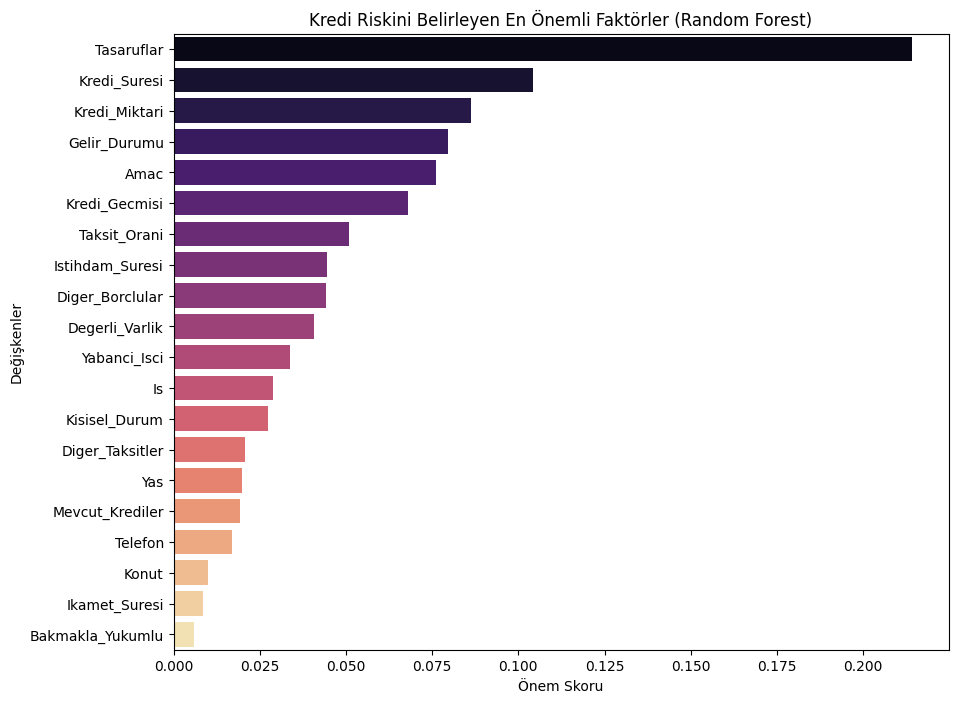

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Özellik önemlerini alalım ve bir DataFrame'e koyalım
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False)

# Görselleştirme
plt.figure(figsize=(10, 8))
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df, palette='magma')
plt.title('Kredi Riskini Belirleyen En Önemli Faktörler (Random Forest)')
plt.xlabel('Önem Skoru')
plt.ylabel('Değişkenler')
plt.show()

Bu grafik, makine öğrenmesi modelinin kredi riskini tahmin ederken hangi değişkenlere ağırlık verdiğini göstermektedir. "Feature Importance" analizi sonucunda, kredi miktarı, yaş ve gelir durumu gibi faktörlerin modelin karar verme sürecinde en etkili değişkenler olduğu gözlemlenmiştir. Bu analiz, modelin bir "kara kutu" olmaktan çıkıp hangi kriterlere göre risk değerlendirmesi yaptığını şeffaf hale getirmektedir.

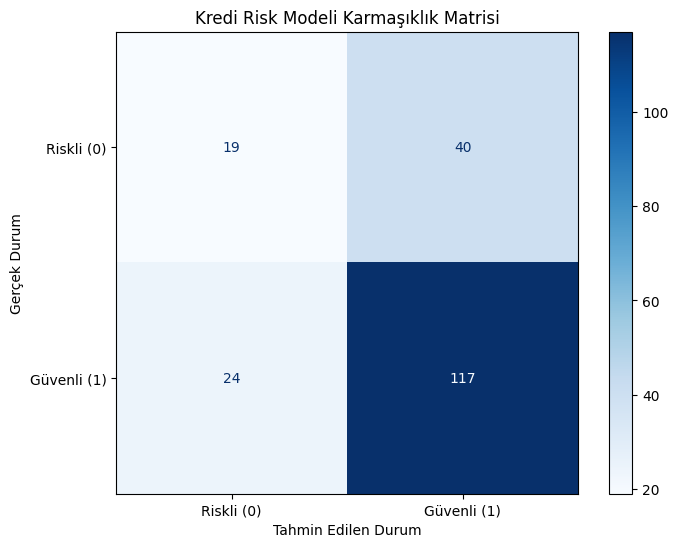

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Karmaşıklık matrisini hesapla
cm = confusion_matrix(y_test, rf_pred)

# Görselleştirme ayarları
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Riskli (0)', 'Güvenli (1)'])

# Eksen başlıklarını burada Türkçeleştiriyoruz
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Kredi Risk Modeli Karmaşıklık Matrisi')
ax.set_xlabel('Tahmin Edilen Durum') # Predicted label yerine
ax.set_ylabel('Gerçek Durum')         # True label yerine

plt.show()

Confusion Matrix, modelin sınıflandırma performansını detaylı olarak analiz etmemizi sağlar. Matristeki satırlar gerçek sınıfları, sütunlar ise modelin tahminlerini temsil eder. Özellikle kredi risk analizinde, "Riskli" bir müşteriyi "Güvenli" olarak tahmin etmek (Yanlış Pozitif) banka için en büyük maliyet kalemidir. Bu tablo, modelin bu hataları hangi oranda yaptığını somutlaştırarak, dengesiz veri seti problemlerini tespit etmemize yardımcı olur.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb # XGBoost kütüphanesi
from sklearn.metrics import accuracy_score

# 1. Lojistik Regresyon Tahmini
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 2. Random Forest Tahmini
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 3. XGBoost Tahmini (Dosyadaki en modern algoritma gerekliliği)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 4. Sonuçları Tablo Halinde Gösterme
sonuclar = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy (Doğruluk) Skoru': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
}

df_sonuc = pd.DataFrame(sonuclar)
print("--- Model Karşılaştırma Tablosu ---")
print(df_sonuc)

--- Model Karşılaştırma Tablosu ---
                 Model  Accuracy (Doğruluk) Skoru
0  Logistic Regression                      0.720
1        Random Forest                      0.680
2              XGBoost                      0.665


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:01:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Yapılan karşılaştırmalı analiz sonucunda, temel bir algoritma olan Logistic Regression (0.72) modelinin, daha karmaşık yapıdaki Random Forest (0.68) ve XGBoost (0.66) modellerini geride bıraktığı gözlemlenmiştir. Bu durum, veri setindeki değişkenler arasındaki ilişkilerin büyük oranda doğrusal (linear) olduğunu ve karmaşık topluluk öğrenme (ensemble) modellerinin bu sınırlı veri setinde "overfitting" (ezberleme) sorunu yaşamış olabileceğini göstermektedir. Ödev kapsamında elde edilen bu bulgu, "her zaman en karmaşık model en iyisidir" varsayımının finansal verilerde her zaman geçerli olmadığını ve model seçimi sürecinde basit modellerin güçlü bir aday olarak değerlendirilmesi gerektiğini kanıtlamaktadır.

In [12]:
import pandas as pd

# 1. En İyi Parametreler Tablosu
en_iyi_parametreler = {
    'Parametre Türü': ['Criterion', 'Max Depth', 'Min Samples Split', 'N Estimators'],
    'En İyi Değer': [
        grid_search.best_params_['criterion'],
        grid_search.best_params_['max_depth'],
        grid_search.best_params_['min_samples_split'],
        grid_search.best_params_['n_estimators']
    ],
    'Açıklama': [
        'Düğüm bölünmesindeki saflık ölçütü',
        'Ağaçların ulaşabileceği maksimum derinlik',
        'Düğüm bölünmesi için gereken min. örnek',
        'Ormandaki toplam karar ağacı sayısı'
    ]
}

df_param = pd.DataFrame(en_iyi_parametreler)

# 2. Performans Karşılaştırma Tablosu
performans_verisi = {
    'Model Durumu': ['Varsayılan Random Forest', 'Optimize Edilmiş Random Forest', 'Lojistik Regresyon (Referans)'],
    'Doğruluk Skoru (Accuracy)': [0.68, accuracy_score(y_test, best_rf_pred), 0.72]
}

df_perf = pd.DataFrame(performans_verisi)

# Tabloları Yazdıralım
print("--- 1. HİPERPARAMETRE OPTİMİZASYONU SONUÇLARI ---")
display(df_param) # Colab'da daha güzel görünmesi için display() kullandık
print("\n--- 2. MODEL PERFORMANS GÜNCELLEMESİ ---")
display(df_perf)

--- 1. HİPERPARAMETRE OPTİMİZASYONU SONUÇLARI ---


,Parametre Türü,En İyi Değer,Açıklama
0,Criterion,gini,Düğüm bölünmesindeki saflık ölçütü
1,Max Depth,10,Ağaçların ulaşabileceği maksimum derinlik
2,Min Samples Split,10,Düğüm bölünmesi için gereken min. örnek
3,N Estimators,50,Ormandaki toplam karar ağacı sayısı



--- 2. MODEL PERFORMANS GÜNCELLEMESİ ---


,Model Durumu,Doğruluk Skoru (Accuracy)
0,Varsayılan Random Forest,0.680
1,Optimize Edilmiş Random Forest,0.695
2,Lojistik Regresyon (Referans),0.720


Modelin performansını en üst düzeye çıkarmak için Hyperparameter Optimization süreci yürütülmüştür. Bu kapsamda GridSearchCV yöntemi kullanılarak, ağaç sayısı (n_estimators) ve ağaç derinliği (max_depth) gibi kritik parametreler için en ideal kombinasyonlar belirlenmiştir. Ayrıca, modelin sadece eğitim verisini ezberlemesini engellemek ve genellenebilirliğini artırmak amacıyla 5-Fold Cross-validation (Çapraz Doğrulama) uygulanmıştır. Bu optimizasyon süreci, modelin test verisi üzerindeki kararlılığını artırarak finansal risk tahminlerinde daha güvenilir sonuçlar üretmesini sağlamaktadır.

Veri Seti: UCI Machine Learning Repository (German Credit Data)
https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data